In [1]:
import numpy as np
import torch
import torch.nn as nn
import math

import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
sns.set_theme(
    style='whitegrid',
    palette='rocket',
)
cmap = plt.colormaps["rocket"]

device = torch.device('cuda:0')

## Create dataset

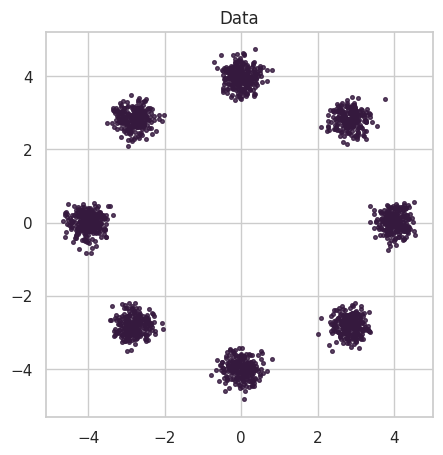

In [2]:
def sample_data(n):
    N_MODES, RADIUS, STD = 8, 4.0, 0.25
    centers = np.stack([(RADIUS*np.cos(2*np.pi*k/N_MODES), RADIUS*np.sin(2*np.pi*k/N_MODES)) for k in range(N_MODES)])

    idx = np.random.randint(0, N_MODES, size=n)
    pts = centers[idx] + STD*np.random.randn(n, 2)
    return torch.tensor(pts, dtype=torch.float32)

data = sample_data(2000)

plt.figure(figsize=(5,5))
plt.scatter(data[:,0], data[:,1], s=7, alpha=0.8)
plt.title('Data')
plt.show()

## Denoiser

In [3]:
def positional_embedding(t, dim, max_period=10000):
    # https://github.com/openai/glide-text2im/blob/main/glide_text2im/nn.py
    half = dim // 2
    freqs = torch.exp(
        -math.log(max_period) * torch.arange(start=0, end=half, dtype=torch.float32) / half
    ).to(device=t.device)
    args = t[:, None].float() * freqs[None]
    embedding = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
    if dim % 2:
        embedding = torch.cat([embedding, torch.zeros_like(embedding[:, :1])], dim=-1)
    return embedding

class MLP(nn.Module):
    def __init__(self, hidden=128, tdim=64):
        super().__init__()
        self.hidden = hidden
        self.tdim = tdim
        self.train_iters = 0

        self.net = nn.Sequential(
            nn.Linear(2 + tdim, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, 2),
        )
        nn.init.zeros_(self.net[-1].weight); nn.init.zeros_(self.net[-1].bias)

    @property
    def device(self):
        return self.net[-1].weight.device

    def forward(self, x, t):
        t_emb = positional_embedding(t.view(x.shape[0]), self.tdim)
        return self.net(torch.cat([x, t_emb], dim=-1))

## Training

In [4]:
from IPython.display import clear_output

cmap = plt.colormaps["rocket"]
c1 = cmap(0.1)
c2 = cmap(0.7)

def viz_step(model, n=2000, tt=0.5, suptitle=None, clear=True):
    if clear:
        clear_output(wait=True)

    data = sample_data(n)
    gen = ode_sample(model, n).cpu().numpy()

    fig, ax = plt.subplots(1, 1, figsize=(5,5))

    # Top singular value of Jacobian at tt
    cg = np.linspace(-5, 5, 25)
    Xc, Yc = np.meshgrid(cg, cg)
    pts = torch.tensor(np.stack([Xc.ravel(), Yc.ravel()],1), dtype=torch.float32, device=model.device)
    ct = torch.full((pts.shape[0],), tt, device=model.device)
    S = top_singval(model, pts, ct)[:,0].cpu().numpy().reshape(Xc.shape)
    im = ax.pcolormesh(Xc, Yc, S, rasterized=True, cmap="gray_r", zorder=0)

    ax.grid(True, zorder=10)
    
    # Generated samples
    ax.scatter(data[:,0], data[:,1], s=5, alpha=1.0, color=c1, label='Real', rasterized=True)
    ax.scatter(gen[:,0], gen[:,1], s=5, alpha=0.8, color=c2, label='Generated', rasterized=True)
    ax.set_title(f'{suptitle} | Samples @ iter {model.train_iters}')
    ax.legend(loc='upper right', markerscale=3)
    
    # Create a separate colorbar
    pos = ax.get_position()
    cax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.05, pos.height-0.2])
    fig.colorbar(
        im, 
        cax=cax,
    )
    ax.set_ylabel(
        '$\lambda_{max}$ ' + f'($t={tt:.2f}$)',
        rotation=270,
        labelpad=60
    )
    ax.yaxis.set_label_position("right")
    
    ax.set_xlim(-5,5)
    ax.set_ylim(-5,5)
    plt.show()

In [5]:
CLAMP = 5e-2

def train_step(model, x):
    batch, _ = x.shape
    t = torch.rand((batch,1), device=x.device)
    eps = torch.randn_like(x)
    xt = (1-t)*eps + t*x
    velocity = (x-xt)/(1-t).clamp_min(CLAMP)

    x0_pred = model(xt, t)
    velocity_pred = (x0_pred - xt)/(1-t).clamp_min(CLAMP)
    velocity_loss = ((velocity_pred - velocity) ** 2).mean()

    return dict(t=t, eps=eps, xt=xt, x0_pred=x0_pred, velocity_pred=velocity_pred, velocity_loss=velocity_loss)

@torch.no_grad()
def ode_sample(model, n, steps=100):
    x = torch.randn(n, 2, device=device)
    ts = torch.linspace(0, 1, steps+1, device=device)
    for i in range(steps):
        t_cur, t_next = ts[i].tile(n,1), ts[i+1].tile(n,1)
        x0_pred = model(x, t_cur)
        velocity_pred = (x0_pred - x)/(1-t_cur).clamp_min(CLAMP)
        x = x + (t_next - t_cur)*velocity_pred
    return x

In [6]:
# Diagnostics
def jacobian_at(model, x, t):
    # Compute dx0/dxt
    x = x.detach().requires_grad_(True)
    out = model(x, t)
    J = torch.zeros(x.shape[0], 2, 2, device=x.device)
    for i in range(2):
        # get dx0_i/dxt_i
        g = torch.autograd.grad(out[:,i].sum(), x, retain_graph=True)[0]
        # assign to J row
        J[:,i,:] = g
    return J.detach()

def top_singval(model, x, t):
    # Top singular value
    J = jacobian_at(model, x, t)
    return torch.linalg.svdvals(J)

### Baseline

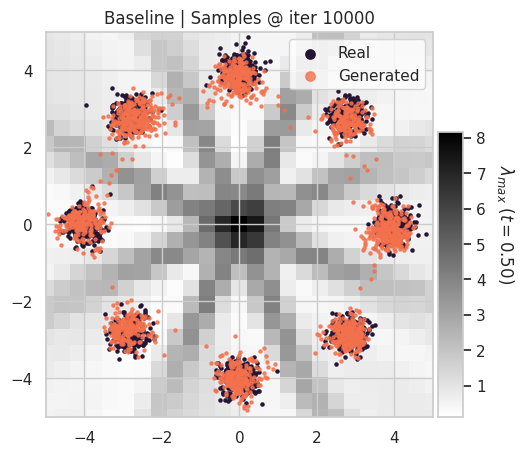

100%|██████████| 10000/10000 [00:54<00:00, 184.16it/s, Velocity loss=3.74]


In [7]:
lr = 2e-3
iters = 10_000
batch_size = 512
viz_every = 500

model = MLP().to(device)
opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.0)

velocity_loss_track = []
progress_bar = tqdm(range(iters))

for it in progress_bar:
    x = sample_data(batch_size).to(device)
    output = train_step(model, x)

    total_loss = output['velocity_loss']

    opt.zero_grad()
    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step()

    # Logging
    velocity_loss_track.append(output['velocity_loss'].item())
    if len(velocity_loss_track) > 500:
        velocity_loss_track = velocity_loss_track[-500:]

    if it % 20 == 0:
        progress_bar.set_postfix({
            "Velocity loss": np.mean(velocity_loss_track),
        })

    if it % viz_every == 0:
        viz_step(model, suptitle='Baseline')
    model.train_iters += 1

viz_step(model, suptitle='Baseline')
progress_bar.set_postfix({
    "Velocity loss": np.mean(velocity_loss_track),
})
print(progress_bar)

### Minimizing Jacobian response

In [8]:
def jacobian_min_reg(model, output, direction='residual'):
    xt, x0_pred, t, eps = output['xt'], output['x0_pred'], output['t'], output['eps']

    # Choose direction towards which to perturb the input
    if direction == 'normal':
        v = torch.randn_like(x)

    elif direction == 'rademacher':
        v = 2*(torch.rand_like(x)<0.5).float()-1
        v = v/v.norm(dim=1, keepdim=True)

    elif direction == 'ortho':
        # +-[0,1] or +-[1,0]
        v = torch.zeros((x.shape[0], 2), device=device)
        idx = torch.randint(2, (x.shape[0],), device=device)
        v.scatter_(1, idx.unsqueeze(1), 1)
        sign = 2*(torch.rand_like(x)<0.5).float()-1
        v = v*sign

    else:
        print("Unknown direction")
        v = torch.zeros_like(x)
    
    # Fixed step size
    k = 1.0

    # Using velocity
    xt_eigen = xt + k*v
    x0_pred_eigen = model(xt_eigen, t)

    vel_eigen = (x-xt_eigen)/(1-t).clamp_min(CLAMP)
    vel_pred_eigen = (x0_pred_eigen-xt_eigen)/(1-t).clamp_min(CLAMP)
    jac_loss = ((vel_pred_eigen - vel_eigen)**2).mean()

    return jac_loss, v


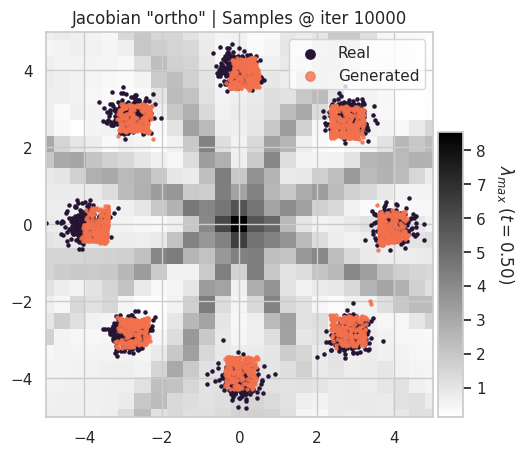

100%|██████████| 10000/10000 [01:47<00:00, 93.23it/s, Velocity loss=3.88, Jacobian loss=9.63]


In [9]:
min_direction = 'ortho'
jacobian_w = 0.1

model_min_jac = MLP().to(device)
opt = torch.optim.AdamW(model_min_jac.parameters(), lr=lr, weight_decay=0.0)

velocity_loss_track = []
jacobian_loss_track = []
progress_bar = tqdm(range(iters))

for it in progress_bar:
    x = sample_data(batch_size).to(device)
    output = train_step(model_min_jac, x)

    total_loss = output['velocity_loss']

    # Jacobian step
    velocity_loss_eigen, v = jacobian_min_reg(
        model_min_jac, output,
        direction=min_direction, 
    )
    total_loss = total_loss + jacobian_w*velocity_loss_eigen

    opt.zero_grad()
    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(model_min_jac.parameters(), 1.0)
    opt.step()

    # Logging
    velocity_loss_track.append(output['velocity_loss'].item())
    jacobian_loss_track.append(velocity_loss_eigen.item())
    if len(velocity_loss_track) > 500:
        velocity_loss_track = velocity_loss_track[-500:]
    if len(jacobian_loss_track) > 500:
        jacobian_loss_track = jacobian_loss_track[-500:]

    if it % 20 == 0:
        progress_bar.set_postfix({
            "Velocity loss": np.mean(velocity_loss_track),
            "Jacobian loss": np.mean(jacobian_loss_track),
        })


    if it % viz_every == 0:
        viz_step(model_min_jac, suptitle=f'Jacobian "{min_direction}"')
    model_min_jac.train_iters += 1

viz_step(model_min_jac, suptitle=f'Jacobian "{min_direction}"')
progress_bar.set_postfix({
    "Velocity loss": np.mean(velocity_loss_track),
    "Jacobian loss": np.mean(jacobian_loss_track),
})
print(progress_bar)

### Maximizing Jacobian response

In [10]:
def jacobian_reg(model, output, direction='residual'):
    xt, x0_pred, t, eps = output['xt'], output['x0_pred'], output['t'], output['eps']

    # Choose direction towards which to perturb the input
    if direction == 'residual':
        v = x0_pred.detach()-x
    elif direction == 'normal':
        v = torch.randn_like(x)
    elif direction == 'mix':
        v = x-x0_pred.detach()
        v[:x.shape[0]//2] = torch.randn_like(v[:x.shape[0]//2])
    elif direction == 'sampling':
        v = x-eps
    else:
        print("Unknown direction")
        v = torch.zeros_like(x)

    # Fixed gain
    k = 10.0

    # Using velocity
    xt_eigen = xt - v/k
    x0_pred_eigen = model(xt_eigen, t)

    vel_eigen = (x-xt_eigen)/(1-t).clamp_min(CLAMP)
    vel_pred_eigen = (x0_pred_eigen-xt_eigen)/(1-t).clamp_min(CLAMP)
    jac_loss = ((vel_pred_eigen - vel_eigen)**2).mean()

    return jac_loss, v


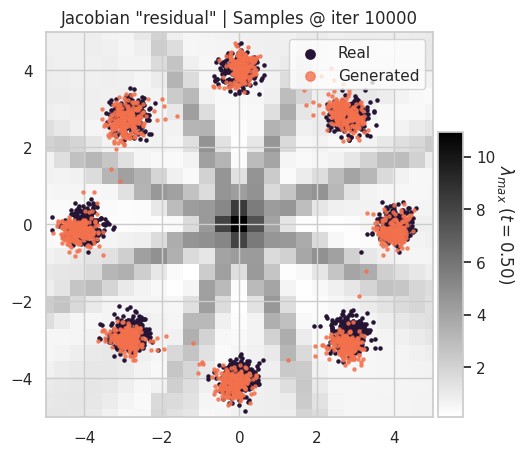

100%|██████████| 10000/10000 [01:45<00:00, 94.87it/s, Velocity loss=3.81, Jacobian loss=2.45]


In [11]:
max_direction = 'residual'
jacobian_w = 1.0

model_jac = MLP().to(device)
opt = torch.optim.AdamW(model_jac.parameters(), lr=lr, weight_decay=0.0)

velocity_loss_track = []
jacobian_loss_track = []
progress_bar = tqdm(range(iters))

for it in progress_bar:
    x = sample_data(batch_size).to(device)
    output = train_step(model_jac, x)

    total_loss = output['velocity_loss']

    # Jacobian step
    velocity_loss_eigen, v = jacobian_reg(
        model_jac, output,
        direction=max_direction, 
    )
    total_loss = total_loss + jacobian_w*velocity_loss_eigen

    opt.zero_grad()
    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(model_jac.parameters(), 1.0)
    opt.step()

    # Logging
    velocity_loss_track.append(output['velocity_loss'].item())
    jacobian_loss_track.append(velocity_loss_eigen.item())
    if len(velocity_loss_track) > 500:
        velocity_loss_track = velocity_loss_track[-500:]
    if len(jacobian_loss_track) > 500:
        jacobian_loss_track = jacobian_loss_track[-500:]

    if it % 20 == 0:
        progress_bar.set_postfix({
            "Velocity loss": np.mean(velocity_loss_track),
            "Jacobian loss": np.mean(jacobian_loss_track),
        })


    if it % viz_every == 0:
        viz_step(model_jac, suptitle=f'Jacobian "{max_direction}"')
    model_jac.train_iters += 1

viz_step(model_jac, suptitle=f'Jacobian "{max_direction}"')
progress_bar.set_postfix({
    "Velocity loss": np.mean(velocity_loss_track),
    "Jacobian loss": np.mean(jacobian_loss_track),
})
print(progress_bar)

## Visualize results

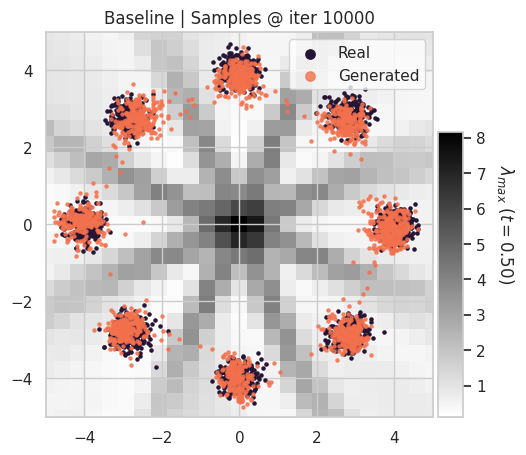

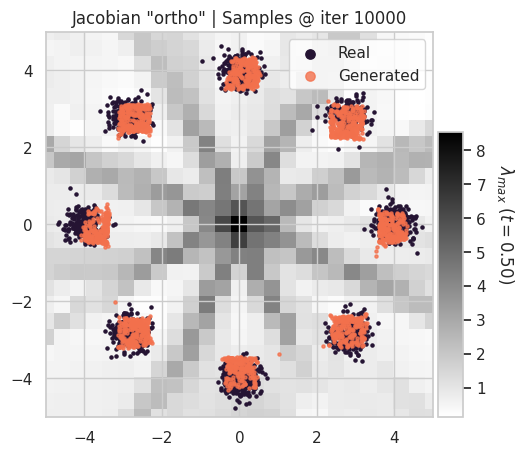

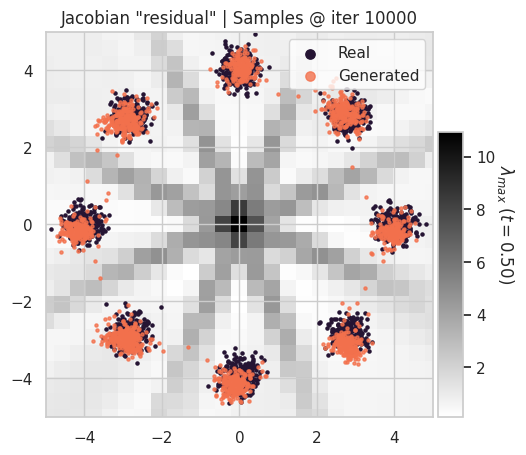

In [12]:
viz_step(model, suptitle='Baseline', clear=False)
viz_step(model_min_jac, suptitle=f'Jacobian "{min_direction}"', clear=False)
viz_step(model_jac, suptitle=f'Jacobian "{max_direction}"', clear=False)

### Appendix: Direct maximization

In [13]:
def jacobian_direct_reg(model, output, direction='residual'):
    xt, x0_pred, t, eps = output['xt'], output['x0_pred'], output['t'], output['eps']

    # Choose direction towards which to perturb the input
    if direction == 'residual':
        v = x0_pred.detach()-x
    elif direction == 'normal':
        v = torch.randn_like(x)
    elif direction == 'mix':
        v = x-x0_pred.detach()
        v[:x.shape[0]//2] = torch.randn_like(v[:x.shape[0]//2])
    elif direction == 'sampling':
        v = x-eps
    else:
        print("Unknown direction")
        v = torch.zeros_like(x)

    # Fixed gain
    k = 5.0

    # Using velocity
    xt_eigen = xt - v/k
    x0_pred_eigen = model(xt_eigen, t)

    vel_pred = (x0_pred-xt)/(1-t).clamp_min(CLAMP)
    vel_pred_eigen = (x0_pred_eigen-xt_eigen)/(1-t).clamp_min(CLAMP)
    jac_loss = -((vel_pred_eigen - vel_pred)**2).mean()

    return jac_loss, v


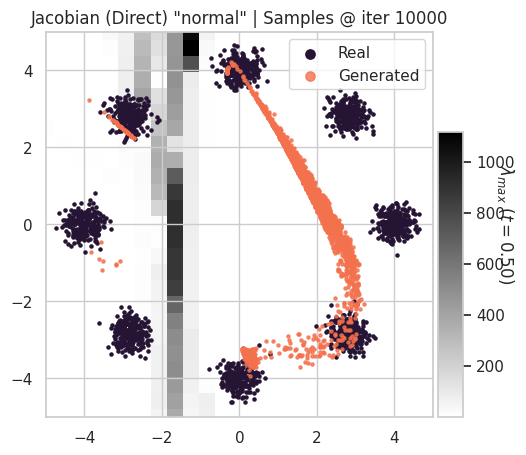

100%|██████████| 10000/10000 [01:48<00:00, 91.75it/s, Velocity loss=1.78e+3, Jacobian loss=-1.74e+3]


In [14]:
max_direction = 'normal'
jacobian_w = 1.0

model_direct_jac = MLP().to(device)
opt = torch.optim.AdamW(model_direct_jac.parameters(), lr=lr, weight_decay=0.0)

velocity_loss_track = []
jacobian_loss_track = []
progress_bar = tqdm(range(iters))

for it in progress_bar:
    x = sample_data(batch_size).to(device)
    output = train_step(model_direct_jac, x)

    total_loss = output['velocity_loss']

    # Jacobian step
    velocity_loss_eigen, v = jacobian_direct_reg(
        model_direct_jac, output,
        direction=max_direction, 
    )
    total_loss = total_loss + jacobian_w*velocity_loss_eigen

    opt.zero_grad()
    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(model_direct_jac.parameters(), 1.0)
    opt.step()

    # Logging
    velocity_loss_track.append(output['velocity_loss'].item())
    jacobian_loss_track.append(velocity_loss_eigen.item())
    if len(velocity_loss_track) > 500:
        velocity_loss_track = velocity_loss_track[-500:]
    if len(jacobian_loss_track) > 500:
        jacobian_loss_track = jacobian_loss_track[-500:]

    if it % 20 == 0:
        progress_bar.set_postfix({
            "Velocity loss": np.mean(velocity_loss_track),
            "Jacobian loss": np.mean(jacobian_loss_track),
        })


    if it % viz_every == 0:
        viz_step(model_direct_jac, suptitle=f'Jacobian "{max_direction}"')
    model_direct_jac.train_iters += 1

viz_step(model_direct_jac, suptitle=f'Jacobian (Direct) "{max_direction}"')
progress_bar.set_postfix({
    "Velocity loss": np.mean(velocity_loss_track),
    "Jacobian loss": np.mean(jacobian_loss_track),
})
print(progress_bar)

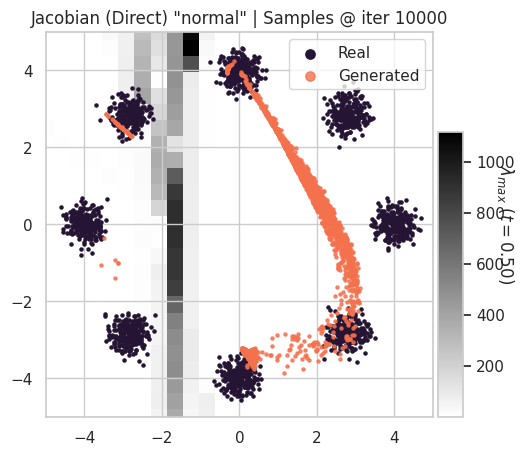

In [15]:
viz_step(model_direct_jac, suptitle=f'Jacobian (Direct) "{max_direction}"', clear=False)